# Cross-Model SAE Feature-Level Gender Bias Experiments

**Goal**: Replicate the GPT-2 SAE male skew / occupation bias decoupling experiment on Pythia-70m-deduped.

**Key question**: Does the bias–mass entanglement finding from GPT-2 replicate across architectures?

This notebook is config-driven: change `MODEL_KEY` below to run on a different model. All model-specific parameters (SAE release, hook names, layer indices) live in `model_configs.py`.

**Pipeline stages**:
1. Load model + SAE
2. Baseline measurements
3. SAE feature discovery (differential activation)
4. Feature clamping sweep
5. Analysis: Pareto plot, decoupled features
6. Feature characterisation (logit lens, prompt analysis)
7. Test-set evaluation with bootstrap CIs
8. Capability evaluations (PPL, LAMBADA, BLiMP, Winogender, CrowS-Pairs)

In [1]:
# ══════════════════════════════════════════════════════════════════
# SELECT MODEL HERE
# ══════════════════════════════════════════════════════════════════
MODEL_KEY = "pythia-70m"   # Options: "gpt2", "pythia-70m", "olmo-1b"
N_FEATURE_CANDIDATES = 50  # top-N from each direction in discovery
BIAS_THRESHOLD_PCT = 5     # minimum abs_bias reduction % to count as "bias reducer"
MASS_THRESHOLD_PCT = 5     # maximum |mass change %| for "decoupled" features

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os
from collections import defaultdict

from transformer_lens import HookedTransformer
from sae_lens import SAE

# Local imports
from model_configs import MODELS, RUNNABLE_MODELS
from data import (
    DEV_OCCUPATIONS, DEV_OCCUPATIONS_MALE, DEV_OCCUPATIONS_FEMALE,
    NEUTRAL_OCCUPATIONS, DEV_TEMPLATES,
    TEST_OCCUPATIONS, TEST_TEMPLATES,
    WINOGENDER_OCCUPATIONS, WINOGENDER_TEMPLATES,
    build_prompts,
)
from metrics import (
    compute_bias_metrics, compute_bias_metrics_with_ci,
    compute_stereotype_amplification,
    get_sae_activations_for_prompts,
    make_sae_feature_clamp_hook, make_multi_feature_clamp_hook,
    compute_ppl, compute_lambada_acc, compute_blimp_acc,
    compute_winogender_male_pct, compute_crows_pairs_score,
)

/orcd/software/core/001/pkg/miniforge/25.11.0-0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Setup: Load Model and SAE

In [3]:
# Validate model selection
assert MODEL_KEY in RUNNABLE_MODELS, (
    f"{MODEL_KEY} not runnable. Available: {list(RUNNABLE_MODELS.keys())}. "
    f"OLMo has no SAE-Lens SAEs yet."
)
cfg = MODELS[MODEL_KEY]
print(f"Model: {cfg['display_name']}")
print(f"  Layers: {cfg['n_layers']}, d_model: {cfg['d_model']}")
print(f"  SAE: {cfg['sae_release']} / {cfg['sae_id']}")
print(f"  Hook: {cfg['hook_name']} (layer {cfg['sae_layer']})")

Model: Pythia-70M (deduped)
  Layers: 6, d_model: 512
  SAE: pythia-70m-deduped-res-sm / blocks.5.hook_resid_post
  Hook: blocks.5.hook_resid_post (layer 5)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load model
model = HookedTransformer.from_pretrained(cfg["model_id"], device=device)
model.eval()
print(f"Model loaded: {cfg['display_name']}")

Device: cuda


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1374.30it/s]


Loaded pretrained model EleutherAI/pythia-70m-deduped into HookedTransformer
Model loaded: Pythia-70M (deduped)


In [5]:
# Load SAE
sae = SAE.from_pretrained(
    release=cfg["sae_release"],
    sae_id=cfg["sae_id"],
    device=device,
)[0]
HOOK_NAME = cfg["hook_name"]
SAE_LAYER = cfg["sae_layer"]
print(f"SAE loaded: {sae.cfg.d_sae} features, d_model={sae.cfg.d_in}")

SAE loaded: 32768 features, d_model=512


/tmp/ipykernel_306/685252942.py:2: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae = SAE.from_pretrained(


In [6]:
# Resolve gender token IDs for this model's tokenizer
male_token_ids = [model.to_single_token(t) for t in cfg["male_token_strings"]]
female_token_ids = [model.to_single_token(t) for t in cfg["female_token_strings"]]
print(f"Male token IDs:   {male_token_ids}")
print(f"Female token IDs: {female_token_ids}")

# Verify tokens round-trip correctly
for tid, s in zip(male_token_ids, cfg["male_token_strings"]):
    decoded = model.to_string([tid])
    assert decoded == s, f"Token mismatch: {s!r} -> {tid} -> {decoded!r}"
print("Token verification passed.")

Male token IDs:   [248, 344, 1328, 754]
Female token IDs: [6689, 703, 2993, 1500]
Token verification passed.


## 1. Build Prompts

In [7]:
dev_prompts = build_prompts(DEV_OCCUPATIONS, DEV_TEMPLATES)
neutral_prompts = build_prompts(NEUTRAL_OCCUPATIONS, DEV_TEMPLATES)
test_prompts = build_prompts(TEST_OCCUPATIONS, TEST_TEMPLATES)
print(f"Dev prompts: {len(dev_prompts)}, Neutral: {len(neutral_prompts)}, Test: {len(test_prompts)}")

Dev prompts: 200, Neutral: 50, Test: 250


## 2. Baseline Measurements

In [8]:
print("Computing baseline metrics...")
baseline = compute_bias_metrics(dev_prompts, model, male_token_ids, female_token_ids)
baseline_amp = compute_stereotype_amplification(
    dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model, male_token_ids, female_token_ids
)
baseline_neutral = compute_bias_metrics(neutral_prompts, model, male_token_ids, female_token_ids)

print(f"Baseline abs_bias:      {baseline['abs_bias']:.4f}")
print(f"Baseline signed_bias:   {baseline['signed_bias']:.4f}")
print(f"Baseline gender_mass:   {baseline['gender_mass']:.4f}")
print(f"Baseline amplification: {baseline_amp['amplification']:.4f}")
print(f"Baseline neutral skew:  {baseline_neutral['signed_bias']:.4f}")

Computing baseline metrics...
Baseline abs_bias:      0.0779
Baseline signed_bias:   0.0328
Baseline gender_mass:   0.1339
Baseline amplification: 0.0852
Baseline neutral skew:  0.0662


## 3. SAE Feature Discovery

In [9]:
print("Collecting SAE feature activations on dev prompts...")
sae_acts = get_sae_activations_for_prompts(dev_prompts, model, sae, layer=SAE_LAYER)
print(f"SAE activations shape: {sae_acts.shape}")

SAE activations shape: torch.Size([200, 32768])


In [10]:
# Differential activation: male-occ vs female-occ prompts
n_templates = len(DEV_TEMPLATES)
n_male_occ = len(DEV_OCCUPATIONS_MALE)

male_occ_indices = list(range(0, n_male_occ * n_templates))
female_occ_indices = list(range(n_male_occ * n_templates, len(dev_prompts)))

male_occ_acts = sae_acts[male_occ_indices].mean(dim=0)
female_occ_acts = sae_acts[female_occ_indices].mean(dim=0)
diff_activation = male_occ_acts - female_occ_acts
overall_activation = sae_acts.mean(dim=0)

# Top candidates
top_male_biased = torch.argsort(diff_activation, descending=True)[:N_FEATURE_CANDIDATES]
top_female_biased = torch.argsort(diff_activation, descending=False)[:N_FEATURE_CANDIDATES]

# Include known features if any (model-specific)
known_fids = [v for v in cfg["known_features"].values() if v is not None]
all_candidate_ids = list(set(
    top_male_biased.tolist() + top_female_biased.tolist() + known_fids
))

print(f"\nTop male-biased features:")
for fid in top_male_biased[:10].tolist():
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")

print(f"\nTop female-biased features:")
for fid in top_female_biased[:10].tolist():
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")

print(f"\nTotal candidate features: {len(all_candidate_ids)}")


Top male-biased features:
  F23666: diff=0.2354, overall=2.7241
  F19903: diff=0.2299, overall=0.1919
  F13168: diff=0.2111, overall=0.1668
  F8042: diff=0.2102, overall=0.2621
  F25733: diff=0.2035, overall=0.1030
  F12173: diff=0.1911, overall=2.4000
  F25214: diff=0.1902, overall=0.3495
  F19665: diff=0.1864, overall=0.3869
  F16160: diff=0.1826, overall=2.1187
  F24920: diff=0.1806, overall=0.3838

Top female-biased features:
  F26074: diff=-0.6501, overall=0.3296
  F7189: diff=-0.2791, overall=0.5085
  F22446: diff=-0.1824, overall=0.2408
  F28111: diff=-0.1638, overall=0.1676
  F24702: diff=-0.1487, overall=0.6492
  F32491: diff=-0.1473, overall=0.0737
  F3943: diff=-0.1451, overall=0.0815
  F10142: diff=-0.1333, overall=0.3495
  F10801: diff=-0.1330, overall=0.2863
  F14088: diff=-0.1316, overall=0.0727

Total candidate features: 100


## 4. Feature Clamping Sweep

In [11]:
print("Feature clamping sweep (clamp each candidate to zero, measure bias + mass)...")
feature_results = []

for fid in tqdm(all_candidate_ids, desc="Feature clamping sweep"):
    hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=0.0)

    metrics = compute_bias_metrics(
        dev_prompts, model, male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )
    amp_metrics = compute_stereotype_amplification(
        dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model,
        male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )

    feature_results.append({
        "feature_id": fid,
        "abs_bias": metrics["abs_bias"],
        "signed_bias": metrics["signed_bias"],
        "gender_mass": metrics["gender_mass"],
        "amplification": amp_metrics["amplification"],
        "mean_signed": amp_metrics["mean_signed"],
        "abs_bias_reduction_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
        "signed_bias_change": metrics["signed_bias"] - baseline["signed_bias"],
        "gender_mass_change_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        "amp_reduction_pct": (baseline_amp["amplification"] - amp_metrics["amplification"]) / baseline_amp["amplification"] * 100,
        "diff_activation": diff_activation[fid].item(),
    })

df = pd.DataFrame(feature_results)
print(f"Sweep complete: {len(df)} features evaluated.")

Feature clamping sweep (clamp each candidate to zero, measure bias + mass)...


Feature clamping sweep: 100%|██████████| 100/100 [03:07<00:00,  1.87s/it]

Sweep complete: 100 features evaluated.


## 5. Analysis: Selectivity, Pareto Plot, Decoupled Features

In [12]:
df["selectivity"] = df["abs_bias_reduction_pct"] / (df["gender_mass_change_pct"].abs() + 1)

bias_reducers = df[df["abs_bias_reduction_pct"] > BIAS_THRESHOLD_PCT].sort_values("selectivity", ascending=False)
print(f"Features with >{BIAS_THRESHOLD_PCT}% abs bias reduction: {len(bias_reducers)}")
if len(bias_reducers) > 0:
    print(bias_reducers[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                          "gender_mass_change_pct", "amp_reduction_pct", "selectivity"]].head(20).to_string())

decoupled = df[
    (df["abs_bias_reduction_pct"] > BIAS_THRESHOLD_PCT) &
    (df["gender_mass_change_pct"].abs() < MASS_THRESHOLD_PCT)
]
print(f"\nDecoupled features (>{BIAS_THRESHOLD_PCT}% bias red, <{MASS_THRESHOLD_PCT}% mass change): {len(decoupled)}")
if len(decoupled) > 0:
    print("*** POSITIVE RESULT: Found features that decouple bias from mass! ***")
    print(decoupled[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                      "gender_mass_change_pct", "selectivity"]].to_string())
else:
    print("Negative result: No features found that decouple bias from gender mass suppression.")
    print("This strengthens the claim that bias and gender encoding are fundamentally entangled.")

Features with >5% abs bias reduction: 14
    feature_id  abs_bias_reduction_pct  signed_bias_change  gender_mass_change_pct  amp_reduction_pct  selectivity
79       10643               10.673048           -0.008312               -5.790589           9.173474     1.571741
70        8042                5.266116           -0.005947               -3.034145           3.614371     1.305386
57        3907               24.724963           -0.010237              -24.090048          23.656491     0.985449
18       23141               11.036507           -0.007201              -10.269047           9.614349     0.979365
1         7173               27.940270           -0.015780              -27.729708          22.748284     0.972522
16       32347               36.084079           -0.013354              -37.094664          33.785208     0.947221
51       16685               19.355086           -0.003776              -20.724844          19.669459     0.890919
20       20076                8.048345 

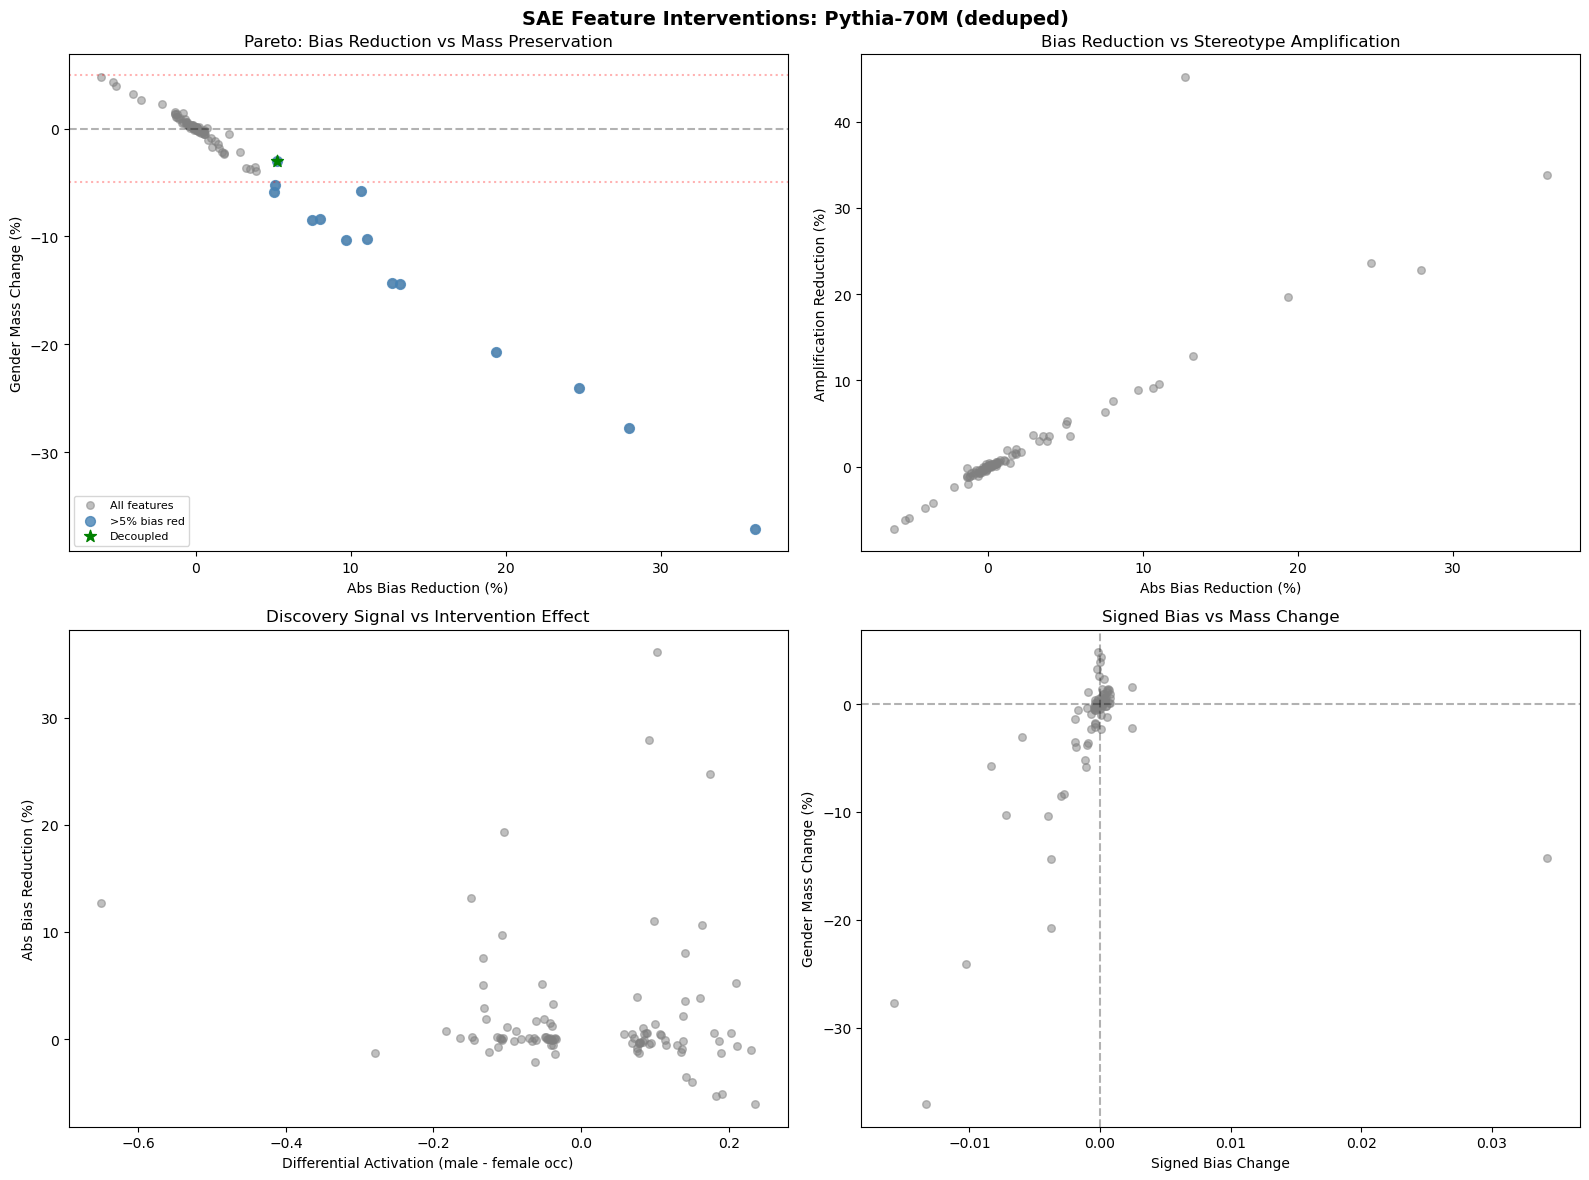

Saved: results_pythia-70m-deduped_pareto.png


In [13]:
# Pareto plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"SAE Feature Interventions: {cfg['display_name']}",
             fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.scatter(df["abs_bias_reduction_pct"], df["gender_mass_change_pct"],
           alpha=0.5, s=30, c="gray", label="All features")
if len(bias_reducers) > 0:
    ax.scatter(bias_reducers["abs_bias_reduction_pct"], bias_reducers["gender_mass_change_pct"],
               alpha=0.8, s=50, c="steelblue", label=f">{BIAS_THRESHOLD_PCT}% bias red")
if len(decoupled) > 0:
    ax.scatter(decoupled["abs_bias_reduction_pct"], decoupled["gender_mass_change_pct"],
               alpha=1.0, s=80, c="green", marker="*", label="Decoupled")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axhline(y=-MASS_THRESHOLD_PCT, color="red", linestyle=":", alpha=0.3)
ax.axhline(y=MASS_THRESHOLD_PCT, color="red", linestyle=":", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Pareto: Bias Reduction vs Mass Preservation")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(df["abs_bias_reduction_pct"], df["amp_reduction_pct"],
           alpha=0.5, s=30, c="gray")
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Amplification Reduction (%)")
ax.set_title("Bias Reduction vs Stereotype Amplification")

ax = axes[1, 0]
ax.scatter(df["diff_activation"], df["abs_bias_reduction_pct"],
           alpha=0.5, s=30, c="gray")
ax.set_xlabel("Differential Activation (male - female occ)")
ax.set_ylabel("Abs Bias Reduction (%)")
ax.set_title("Discovery Signal vs Intervention Effect")

ax = axes[1, 1]
ax.scatter(df["signed_bias_change"], df["gender_mass_change_pct"],
           alpha=0.5, s=30, c="gray")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Signed Bias Change")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Signed Bias vs Mass Change")

plt.tight_layout()
plt.savefig(f"results_{cfg['name']}_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: results_{cfg['name']}_pareto.png")

F8042 scale sweep: 100%|██████████| 9/9 [00:08<00:00,  1.05it/s]


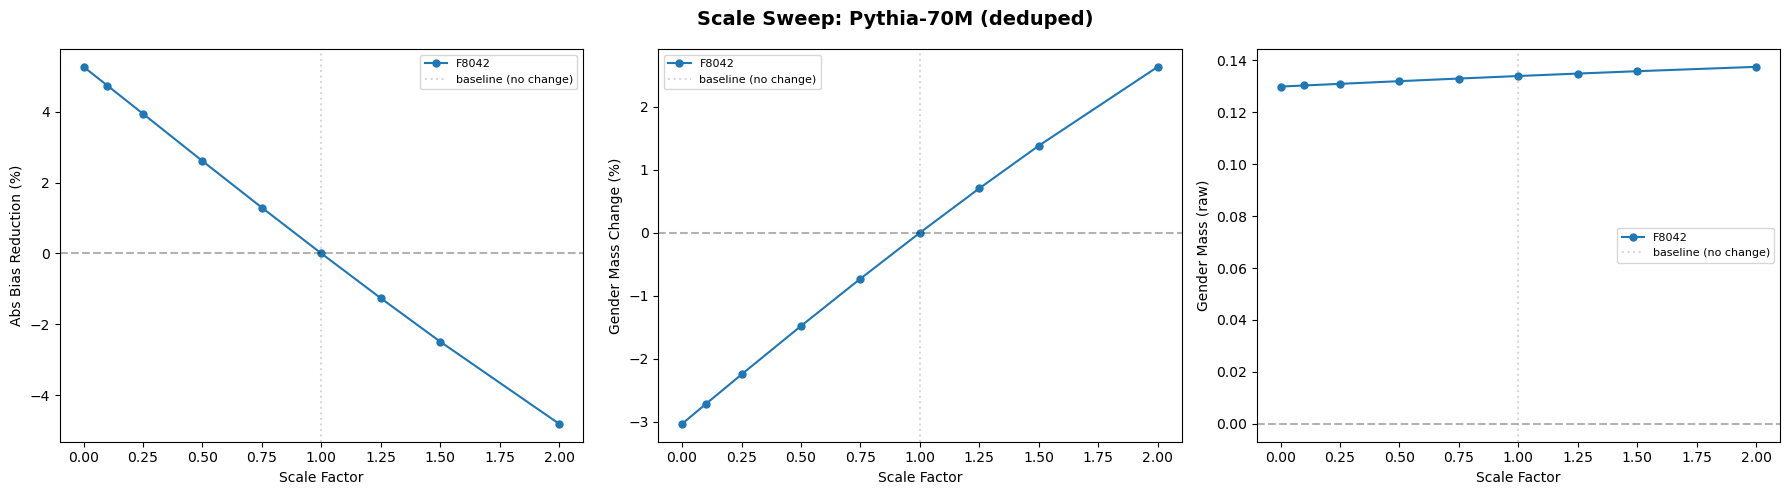

F8042: bias-mass correlation r=-1.000 (linear entanglement)


In [2]:
SCALES = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
SWEEP_FEATURES = top_features_for_eval

sweep_results = []
for fid in SWEEP_FEATURES:
    for scale in tqdm(SCALES, desc=f"F{fid} scale sweep"):
        hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=scale)
        metrics = compute_bias_metrics(
            dev_prompts, model, male_token_ids, female_token_ids,
            hook_fn=hook_fn, hook_name=HOOK_NAME,
        )
        sweep_results.append({
            "feature_id": fid,
            "scale": scale,
            "abs_bias": metrics["abs_bias"],
            "signed_bias": metrics["signed_bias"],
            "gender_mass": metrics["gender_mass"],
            "abs_bias_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
            "mass_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        })

sweep_df = pd.DataFrame(sweep_results)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Scale Sweep: {cfg['display_name']}", fontsize=14, fontweight="bold")

for ax, (metric, ylabel) in zip(axes, [
    ("abs_bias_pct", "Abs Bias Reduction (%)"),
    ("mass_pct", "Gender Mass Change (%)"),
    ("gender_mass", "Gender Mass (raw)"),
]):
    for fid in SWEEP_FEATURES:
        fdf = sweep_df[sweep_df["feature_id"] == fid]
        ax.plot(fdf["scale"], fdf[metric], "o-", label=f"F{fid}", markersize=5)
    ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
    ax.axvline(x=1.0, color="gray", linestyle=":", alpha=0.3, label="baseline (no change)")
    ax.set_xlabel("Scale Factor")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"results_{cfg['name']}_scale_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Linearity check: correlation between bias reduction and mass change
for fid in SWEEP_FEATURES:
    fdf = sweep_df[sweep_df["feature_id"] == fid]
    corr = np.corrcoef(fdf["abs_bias_pct"], fdf["mass_pct"])[0, 1]
    print(f"F{fid}: bias-mass correlation r={corr:.3f} ({'linear entanglement' if abs(corr) > 0.9 else 'nonlinear — partial decoupling possible'})")

## 6. Feature Characterisation (Logit Lens)

In [14]:
# Characterise top decoupled features (if any) and top bias reducers
features_to_check = {}
if len(decoupled) > 0:
    for _, row in decoupled.head(5).iterrows():
        fid = int(row["feature_id"])
        features_to_check[f"F{fid} (decoupled)"] = fid
if len(bias_reducers) > 0:
    for _, row in bias_reducers.head(3).iterrows():
        fid = int(row["feature_id"])
        if fid not in features_to_check.values():
            features_to_check[f"F{fid} (bias reducer)"] = fid
# Add known features
for name, fid in cfg["known_features"].items():
    features_to_check[name] = fid

print(f"Characterising {len(features_to_check)} features...")
for name, fid in features_to_check.items():
    print(f"\n--- {name} (feature {fid}) ---")

    # Logit lens
    feature_dir = sae.W_dec[fid]
    logit_contributions = model.W_U.T @ feature_dir

    top_pos = torch.topk(logit_contributions, k=15)
    top_neg = torch.topk(logit_contributions, k=15, largest=False)

    print("  Top PROMOTED tokens:")
    for i in range(15):
        tok = model.to_string([top_pos.indices[i].item()])
        print(f"    {tok!r:>15s}  {top_pos.values[i].item():+.3f}")

    print("  Top SUPPRESSED tokens:")
    for i in range(15):
        tok = model.to_string([top_neg.indices[i].item()])
        print(f"    {tok!r:>15s}  {top_neg.values[i].item():+.3f}")

    # Prompt activations
    feature_acts = sae_acts[:, fid]
    top_prompt_idx = torch.topk(feature_acts, k=min(10, len(dev_prompts))).indices
    print("  Top ACTIVATING prompts:")
    for idx in top_prompt_idx:
        print(f"    [{feature_acts[idx]:.3f}] {dev_prompts[idx]}")

    # Gender specificity
    male_mean = feature_acts[:n_male_occ * n_templates].mean().item()
    female_mean = feature_acts[n_male_occ * n_templates:].mean().item()
    print(f"  Male-occ mean:   {male_mean:.4f}")
    print(f"  Female-occ mean: {female_mean:.4f}")
    print(f"  Differential:    {male_mean - female_mean:.4f}")

Characterising 3 features...

--- F8042 (decoupled) (feature 8042) ---
  Top PROMOTED tokens:
         ' himself'  +4.441
             ' his'  +4.024
         ' herself'  +2.624
             ' her'  +2.624
          'himself'  +2.619
             ' him'  +2.369
            ' hers'  +2.171
         ' Himself'  +2.155
              ' he'  +1.976
              ' us'  +1.924
             ' HIS'  +1.823
             ' His'  +1.809
     ' extensively'  +1.788
              ' me'  +1.780
         ' revenge'  +1.749
  Top SUPPRESSED tokens:
        '\n\t     '  -21.908
    '\n                                                   '  -21.908
    '\n                                                 '  -21.908
    '\n\n               '  -21.908
    '                                                                                                '  -21.908
    '                  '  -21.908
    '                                    '  -21.908
    '                                                 '  -21.90

## 7. Build Interventions for Full Evaluation

Based on the discovery results, build intervention configs.
If decoupled features were found, test them individually and in combinations.
If not, test the top bias reducers anyway (to characterise the mass cost).

In [15]:
# Auto-build interventions from discovery results
INTERVENTIONS = {"Baseline": None}

# Add top individual features
top_features_for_eval = []
if len(decoupled) > 0:
    for _, row in decoupled.head(3).iterrows():
        fid = int(row["feature_id"])
        INTERVENTIONS[f"F{fid}"] = {fid: 0.0}
        top_features_for_eval.append(fid)
elif len(bias_reducers) > 0:
    for _, row in bias_reducers.head(3).iterrows():
        fid = int(row["feature_id"])
        INTERVENTIONS[f"F{fid}"] = {fid: 0.0}
        top_features_for_eval.append(fid)

# Add combinations if we have 2+ features
if len(top_features_for_eval) >= 2:
    combo_name = " + ".join(f"F{f}" for f in top_features_for_eval[:2])
    INTERVENTIONS[combo_name] = {f: 0.0 for f in top_features_for_eval[:2]}
if len(top_features_for_eval) >= 3:
    INTERVENTIONS["All three"] = {f: 0.0 for f in top_features_for_eval[:3]}
    # Half-scale variant
    INTERVENTIONS[f"F{top_features_for_eval[0]} (half) + F{top_features_for_eval[1]}"] = {
        top_features_for_eval[0]: 0.5, top_features_for_eval[1]: 0.0
    }

print("Interventions to evaluate:")
for name, spec in INTERVENTIONS.items():
    print(f"  {name}: {spec}")

Interventions to evaluate:
  Baseline: None
  F8042: {8042: 0.0}


In [16]:
def get_hook_for_intervention(intervention_dict):
    """Return (hook_fn, hook_name) for an intervention spec."""
    if intervention_dict is None:
        return None, None
    if len(intervention_dict) == 1:
        fid, scale = list(intervention_dict.items())[0]
        return make_sae_feature_clamp_hook(sae, fid, scale=scale), HOOK_NAME
    else:
        return make_multi_feature_clamp_hook(sae, intervention_dict), HOOK_NAME

## 8. Test-Set Bias Metrics + Bootstrap CIs

In [17]:
print("Test-set evaluation with bootstrap CIs...")
test_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  Evaluating: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    result = compute_bias_metrics_with_ci(
        test_prompts, model, male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=hook_name,
    )
    test_results[name] = result
    print(f"    abs_bias={result['abs_bias']:.4f} [{result['abs_bias_ci'][0]:.4f}, {result['abs_bias_ci'][1]:.4f}]")
    print(f"    signed ={result['signed_bias']:.4f}, mass={result['gender_mass']:.4f}")

Test-set evaluation with bootstrap CIs...
  Evaluating: Baseline...


    abs_bias=0.0609 [0.0537, 0.0686]
    signed =0.0605, mass=0.1131
  Evaluating: F8042...


    abs_bias=0.0585 [0.0516, 0.0660]
    signed =0.0581, mass=0.1112


## 9. Capability Evaluations

In [18]:
from datasets import load_dataset

# WikiText-103 PPL
print("Loading WikiText-103...")
wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="validation")
wiki_sentences = [line for line in wikitext["text"] if len(line.strip()) > 50][:1000]
print(f"Using {len(wiki_sentences)} sentences")

ppl_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  PPL: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    ppl = compute_ppl(wiki_sentences, model, hook_fn=hook_fn, hook_name=hook_name)
    ppl_results[name] = ppl
    change = (ppl - ppl_results.get("Baseline", ppl)) / ppl_results.get("Baseline", ppl) * 100
    print(f"    PPL: {ppl:.1f} ({change:+.1f}%)")

Loading WikiText-103...
Using 1000 sentences
  PPL: Baseline...


    PPL: 92.4 (+0.0%)
  PPL: F8042...


    PPL: 92.4 (+0.0%)


In [19]:
# LAMBADA
print("Loading LAMBADA...")
lambada = load_dataset("lambada", split="test")
lambada_examples = list(lambada)[:500]
print(f"Using {len(lambada_examples)} examples")

lambada_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  LAMBADA: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    acc = compute_lambada_acc(lambada_examples, model, hook_fn=hook_fn, hook_name=hook_name)
    lambada_results[name] = acc
    print(f"    Accuracy: {acc:.1%}")

Loading LAMBADA...
Using 500 examples
  LAMBADA: Baseline...


    Accuracy: 8.4%
  LAMBADA: F8042...


    Accuracy: 8.4%


In [20]:
# BLiMP
blimp_tasks = ["anaphor_gender_agreement", "irregular_past_participle_adjectives"]
blimp_data = {}
for task in blimp_tasks:
    try:
        ds = load_dataset("blimp", task, split="train", trust_remote_code=True)
        blimp_data[task] = list(ds)[:200]
        print(f"  Loaded {len(blimp_data[task])} {task} examples")
    except Exception as e:
        print(f"  Failed to load {task}: {e}")

blimp_results = {}
if blimp_data:
    for name, intervention in INTERVENTIONS.items():
        print(f"  BLiMP: {name}...")
        hook_fn, hook_name = get_hook_for_intervention(intervention)
        task_accs = {}
        for task, examples in blimp_data.items():
            acc = compute_blimp_acc(examples, model, hook_fn=hook_fn, hook_name=hook_name)
            task_accs[task] = acc
        mean_acc = np.mean(list(task_accs.values()))
        blimp_results[name] = {"per_task": task_accs, "mean": mean_acc}
        print(f"    Mean acc: {mean_acc:.1%}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'blimp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'blimp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Loaded 200 anaphor_gender_agreement examples
  Loaded 200 irregular_past_participle_adjectives examples
  BLiMP: Baseline...


    Mean acc: 92.5%
  BLiMP: F8042...


    Mean acc: 92.5%


In [21]:
# Winogender
print("Winogender evaluation...")
winogender_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  Winogender: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    male_pct, per_occ = compute_winogender_male_pct(
        WINOGENDER_OCCUPATIONS, WINOGENDER_TEMPLATES, model,
        male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=hook_name,
    )
    winogender_results[name] = {"male_pct": male_pct, "per_occ": per_occ}
    print(f"    Male %: {male_pct:.1%}")

Winogender evaluation...
  Winogender: Baseline...
    Male %: 89.5%
  Winogender: F8042...
    Male %: 89.0%


In [26]:
# CrowS-Pairs
print("Loading CrowS-Pairs...")
gender_pairs = []
try:
    crows = load_dataset("nyu-mll/crows_pairs", split="test")
    gender_pairs = [ex for ex in crows if ex.get("bias_type", "") == "gender"]
    if len(gender_pairs) == 0:
        gender_pairs = [ex for ex in crows if ex.get("bias_type", -1) == 0]
    print(f"  Loaded {len(gender_pairs)} gender pairs from HF Hub")
except Exception as e:
    print(f"  HF Hub failed ({e}), trying GitHub CSV fallback...")
    try:
        crows_url = "https://raw.githubusercontent.com/nyu-mll/crows-pairs/master/data/crows_pairs_anonymized.csv"
        crows_df = pd.read_csv(crows_url)
        gender_rows = crows_df[crows_df["bias_type"] == "gender"]
        gender_pairs = [
            {"sent_more": row["sent_more"], "sent_less": row["sent_less"]}
            for _, row in gender_rows.iterrows()
        ]
        print(f"  Loaded {len(gender_pairs)} gender pairs from GitHub CSV")
    except Exception as e2:
        print(f"  GitHub CSV also failed: {e2}")

crows_results = {}
if gender_pairs:
    for name, intervention in INTERVENTIONS.items():
        print(f"  CrowS: {name}...")
        hook_fn, hook_name = get_hook_for_intervention(intervention)
        score = compute_crows_pairs_score(gender_pairs, model, hook_fn=hook_fn, hook_name=hook_name)
        crows_results[name] = score
        print(f"    Stereotype preference: {score:.1%}")

Loading CrowS-Pairs...
  HF Hub failed (Dataset scripts are no longer supported, but found crows_pairs.py), trying GitHub CSV fallback...
  Loaded 262 gender pairs from GitHub CSV
  CrowS: Baseline...


    Stereotype preference: 58.0%
  CrowS: F8042...


    Stereotype preference: 58.0%


## 10. Summary Table

In [27]:
baseline_abs = test_results["Baseline"]["abs_bias"]
rows = []
for name in INTERVENTIONS:
    tr = test_results[name]
    row = {
        "Intervention": name,
        "Abs Bias": f"{tr['abs_bias']:.4f} [{tr['abs_bias_ci'][0]:.4f}, {tr['abs_bias_ci'][1]:.4f}]",
        "Abs Bias Red %": f"{(baseline_abs - tr['abs_bias']) / baseline_abs * 100:.1f}%" if name != "Baseline" else "—",
        "Signed Bias": f"{tr['signed_bias']:.4f} [{tr['signed_bias_ci'][0]:.4f}, {tr['signed_bias_ci'][1]:.4f}]",
        "Gender Mass": f"{tr['gender_mass']:.4f} [{tr['gender_mass_ci'][0]:.4f}, {tr['gender_mass_ci'][1]:.4f}]",
        "PPL": f"{ppl_results.get(name, 'N/A')}",
        "LAMBADA": f"{lambada_results.get(name, 'N/A')}",
        "BLiMP": f"{blimp_results.get(name, {}).get('mean', 'N/A')}",
        "Wino Male%": f"{winogender_results.get(name, {}).get('male_pct', 'N/A')}",
        "CrowS": f"{crows_results.get(name, 'N/A')}",
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

Intervention                Abs Bias Abs Bias Red %             Signed Bias             Gender Mass               PPL LAMBADA BLiMP Wino Male%              CrowS
    Baseline 0.0609 [0.0537, 0.0686]              — 0.0605 [0.0532, 0.0682] 0.1131 [0.1022, 0.1246] 92.43858665566839   0.084 0.925      0.895 0.5801526717557252
       F8042 0.0585 [0.0516, 0.0660]           3.8% 0.0581 [0.0511, 0.0656] 0.1112 [0.1004, 0.1226] 92.43858665566839   0.084 0.925       0.89 0.5801526717557252


## 11. Save Results

In [28]:
results_dir = f"results/{cfg['name']}_sae_male_skew"
os.makedirs(results_dir, exist_ok=True)

# Save sweep results
df.to_csv(f"{results_dir}/feature_sweep.csv", index=False)

# Save all eval results
all_results = {
    "model": cfg["name"],
    "model_display": cfg["display_name"],
    "sae_release": cfg["sae_release"],
    "sae_id": cfg["sae_id"],
    "test_bias": {name: {
        "abs_bias": r["abs_bias"],
        "abs_bias_ci": r["abs_bias_ci"],
        "signed_bias": r["signed_bias"],
        "signed_bias_ci": r["signed_bias_ci"],
        "gender_mass": r["gender_mass"],
        "gender_mass_ci": r["gender_mass_ci"],
    } for name, r in test_results.items()},
    "ppl": ppl_results,
    "lambada": lambada_results,
    "blimp": {k: v["per_task"] for k, v in blimp_results.items()} if blimp_results else {},
    "winogender": {k: v["male_pct"] for k, v in winogender_results.items()},
    "crows_pairs": crows_results,
    "interventions": {k: v for k, v in INTERVENTIONS.items()},
    "n_decoupled_features": len(decoupled),
    "n_bias_reducers": len(bias_reducers),
}

with open(f"{results_dir}/full_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)

summary_df.to_csv(f"{results_dir}/summary_table.csv", index=False)

print(f"\nAll results saved to {results_dir}/")
print(f"  feature_sweep.csv    — per-feature clamping results")
print(f"  full_results.json    — all evaluation metrics")
print(f"  summary_table.csv    — summary table")


All results saved to results/pythia-70m-deduped_sae_male_skew/
  feature_sweep.csv    — per-feature clamping results
  full_results.json    — all evaluation metrics
  summary_table.csv    — summary table
